# FrozenLake
Read more at:

https://medium.com/swlh/frozen-lake-as-a-markov-decision-process-1692815ecfd1


https://zoo.cs.yale.edu/classes/cs470/materials/hws/hw7/FrozenLake.html

Documentation:
https://gymnasium.farama.org/environments/toy_text/frozen_lake/

In [1]:
# frozen-lake-ex3.py
import gymnasium as gym
from gymnasium.envs.toy_text.frozen_lake import generate_random_map
import numpy as np
import pickle
import matplotlib.pyplot as plt

## 1- Manuell policy

In [9]:
def my_policy_frozenlake(slippery, my_policy):

    # Actions in human language
    actions = {
        'Left': 0,
        'Down': 1,
        'Right': 2, 
        'Up': 3
    }
    
    env = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=slippery, render_mode="human")
    env.reset()
    env.render()

    for a in my_policy:
        new_state, reward, done, truncated, info = env.step(actions[a])
        env.render()
        print("Action:",a)
        print("Position:",new_state)
        if done:
            if reward == 1:
                print("****You reached the goal!****")
            else:
                print("****You fell through a hole!****")
            break
    env.close()

# Variabler
slippery=False
my_policy = ['Right'] + ['Right'] + ['Down'] + ['Down'] + ['Down'] + ['Right'] + ['Right'] + ['Down'] + ['Down'] + ['Right'] + ['Down'] + ['Down'] + ['Right'] + ['Right']
my_policy_frozenlake(slippery, my_policy)

Action: Right
Position: 1
Action: Right
Position: 2
Action: Down
Position: 10
Action: Down
Position: 18
Action: Down
Position: 26
Action: Right
Position: 27
Action: Right
Position: 28
Action: Down
Position: 36
Action: Down
Position: 44
Action: Right
Position: 45
Action: Down
Position: 53
Action: Down
Position: 61
Action: Right
Position: 62
Action: Right
Position: 63
****You reached the goal!****


## resultat
Med en manuell policy kommer den såklart i mål med slippery FALSE men med slippery TRUE är chansen extremt låg, den får inte halka en enda gång på hela vägen dit. (3.42% chans att komma i mål)

## 2 - Träna en agent

In [7]:
def my_frozenlake(episodes, slippery, is_training=True, render=False):

    # print("--- Super amazing policy that will win! ---")
    # print(my_policy)
    # print("Maze is slippery: ", slippery)

    env = gym.make('FrozenLake-v1', map_name='8x8', is_slippery=slippery, render_mode='human' if render else None)
    # env.reset()
    # env.render()
    
    if(is_training):
        q = np.zeros((env.observation_space.n, env.action_space.n)) # init a 64 x 4 array
    else:
        f = open('frozen_lake8x8.pkl', 'rb')
        q = pickle.load(f)
        f.close()

        action_keys = list(actions.keys())

        best_actions = np.argmax(q, axis=1)

        # Printar ut bästa "action" för varje state
        for state, action in enumerate(best_actions):
            print(f"State: {state}, Action: {action_keys[action]}")
        
    
    # Referens: How to Solve Gymnasium FrozenLake-v1 with Python & Q-Learning | Reinforcement Learning Tutorial 1 | https://www.youtube.com/watch?v=ZhoIgo3qqLU
    learning_rate_a = 0.9
    discount_factor_g = 0.9
    epsilon = 1
    epsilon_decay_rate = 0.00005
    rng = np.random.default_rng()

    rewards_per_episode = np.zeros(episodes)
    

    for i in range(episodes):
        state = env.reset()[0]
        terminated = False
        truncated = False


        while(not terminated and not truncated):
            if is_training and rng.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(q[state,:])

            new_state, reward, terminated, truncated, _ = env.step(action)

            if is_training:
                q[state,action] = q[state,action] + learning_rate_a * (
                    reward + discount_factor_g * np.max(q[new_state,:]) - q[state,action]
                )

            state = new_state

        epsilon = max(epsilon - epsilon_decay_rate, 0)

        if(epsilon==0):
            learning_rate_a = 0.0001

        if reward == 1:
            rewards_per_episode[i] = 1
    
    env.close()

    sum_rewards = np.zeros(episodes)
    for t in range(episodes):
        sum_rewards[t] = np.sum(rewards_per_episode[max(0, t-100):(t+1)])
    plt.plot(sum_rewards)
    plt.savefig('frozen_lake8x8.png')

    if is_training:
        f = open('frozen_lake8x8.pkl','wb')
        pickle.dump(q, f)
        f.close()


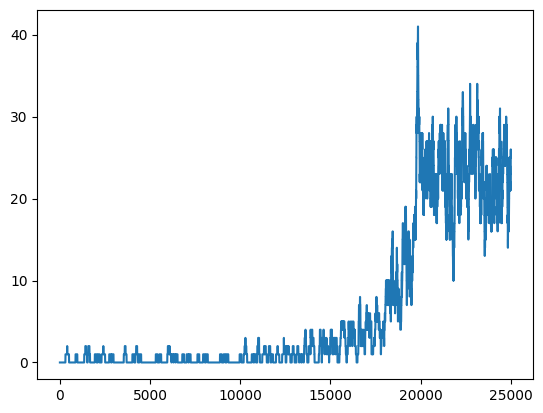

In [4]:
# Kör functionen!
my_frozenlake(25000, True, is_training=True, render=False)

In [10]:
    actions = {
        'Left': 0,
        'Down': 1,
        'Right': 2, 
        'Up': 3
    }

f = open('frozen_lake8x8.pkl', 'rb')
q = pickle.load(f)
f.close()

action_keys = list(actions.keys())

best_actions = np.argmax(q, axis=1)

# Printar ut bästa "action" för varje state
for state, action in enumerate(best_actions):
    print(f"State: {state}, Action: {action_keys[action]}")

NameError: name 'actions' is not defined

Med my_policy = ['Right'] + ['Right'] + ['Right'] + ['Right'] + ['Right'] + ['Right'] + ['Right'] + ['Down'] + ['Down'] + ['Down'] + ['Down'] + ['Down'] + ['Down'] + ['Down'] kommer den lätt till målet såklart om slippery=False, men med slippery=True har den ingen chans.

Följde videon (https://www.youtube.com/watch?v=ZhoIgo3qqLU) för att implementera Q-learning för att lösa problemet.

Exempel policy som implementationen kommer på med:

State: 0, Action: Down
State: 1, Action: Right
State: 2, Action: Up
State: 3, Action: Right
State: 4, Action: Down
State: 5, Action: Right
State: 6, Action: Down
State: 7, Action: Right
State: 8, Action: Up
State: 9, Action: Up
State: 10, Action: Right
State: 11, Action: Up
State: 12, Action: Up
State: 13, Action: Up
State: 14, Action: Left
State: 15, Action: Down
State: 16, Action: Right
State: 17, Action: Up
State: 18, Action: Left
State: 19, Action: Left
State: 20, Action: Right
State: 21, Action: Up
State: 22, Action: Right
State: 23, Action: Down
State: 24, Action: Up
State: 25, Action: Up
State: 26, Action: Left
State: 27, Action: Down
State: 28, Action: Right
State: 29, Action: Left
State: 30, Action: Right
State: 31, Action: Down
State: 32, Action: Up
State: 33, Action: Up
State: 34, Action: Left
State: 35, Action: Left
State: 36, Action: Left
State: 37, Action: Down
State: 38, Action: Up
State: 39, Action: Down
State: 40, Action: Right
State: 41, Action: Left
State: 42, Action: Left
State: 43, Action: Down
State: 44, Action: Right
State: 45, Action: Left
State: 46, Action: Left
State: 47, Action: Right
State: 48, Action: Left
State: 49, Action: Left
State: 50, Action: Up
State: 51, Action: Right
State: 52, Action: Left
State: 53, Action: Left
State: 54, Action: Left
State: 55, Action: Right
State: 56, Action: Left
State: 57, Action: Down
State: 58, Action: Right
State: 59, Action: Left
State: 60, Action: Left
State: 61, Action: Right
State: 62, Action: Down
State: 63, Action: Left

Den är såklart bättre än manuella policyn för att den är mera "dynamisk" och kan bättre ta i beaktan slipperyness, men den är inte såklart perfekt för att enligt grafen kommer den i mål bara ~50% av gångerna. Vi försökte sjustera olika värden och fick att den var mera konsistent med att ge den mera runs och minska på epsilon_decay_rate, men fick inte en mycket högre success rate.